In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.endswith('.zip'):
            print(os.path.join(root, file))

/content/drive/MyDrive/chest_xray.zip


In [6]:
ZIP_PATH = "/content/drive/MyDrive/chest_xray.zip"

In [7]:
import zipfile
import os

EXTRACT_PATH = "/content/chest_xray_dataset"

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Extraction completed")

Extraction completed


In [8]:
import os

for root, dirs, files in os.walk(EXTRACT_PATH):
    print(root)
    if root.count("/") > 6:
        continue

/content/chest_xray_dataset
/content/chest_xray_dataset/chest_xray
/content/chest_xray_dataset/chest_xray/train
/content/chest_xray_dataset/chest_xray/train/PNEUMONIA
/content/chest_xray_dataset/chest_xray/train/NORMAL
/content/chest_xray_dataset/chest_xray/__MACOSX
/content/chest_xray_dataset/chest_xray/__MACOSX/chest_xray
/content/chest_xray_dataset/chest_xray/__MACOSX/chest_xray/train
/content/chest_xray_dataset/chest_xray/__MACOSX/chest_xray/train/PNEUMONIA
/content/chest_xray_dataset/chest_xray/__MACOSX/chest_xray/train/NORMAL
/content/chest_xray_dataset/chest_xray/__MACOSX/chest_xray/val
/content/chest_xray_dataset/chest_xray/__MACOSX/chest_xray/val/PNEUMONIA
/content/chest_xray_dataset/chest_xray/__MACOSX/chest_xray/val/NORMAL
/content/chest_xray_dataset/chest_xray/__MACOSX/chest_xray/test
/content/chest_xray_dataset/chest_xray/__MACOSX/chest_xray/test/PNEUMONIA
/content/chest_xray_dataset/chest_xray/__MACOSX/chest_xray/test/NORMAL
/content/chest_xray_dataset/chest_xray/val
/con

In [9]:
DATASET_PATH = "/content/chest_xray_dataset/chest_xray"

In [10]:
import os

print(os.listdir(DATASET_PATH))

['train', '__MACOSX', 'val', 'test', 'chest_xray']


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [12]:
IMG_SIZE = 150
BATCH_SIZE = 32

train_dir = DATASET_PATH + "/train"
val_dir = DATASET_PATH + "/val"
test_dir = DATASET_PATH + "/test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_data = test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [13]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',
                 input_shape=(150,150,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D())

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1,activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,377 (18.42 MB)

 Trainable params: 4,828,929 (18.42 MB)

 Non-trainable params: 448 (1.75 KB)

In [16]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 428s 3s/step - accuracy: 0.9204 - loss: 0.2154 - val_accuracy: 0.5000 - val_loss: 16.3493
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 433s 3s/step - accuracy: 0.9289 - loss: 0.2044 - val_accuracy: 0.6250 - val_loss: 0.7259
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 417s 3s/step - accuracy: 0.9312 - loss: 0.1946 - val_accuracy: 0.5625 - val_loss: 9.0085
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 427s 3s/step - accuracy: 0.9149 - loss: 0.2258 - val_accuracy: 0.6250 - val_loss: 0.8983
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 422s 3s/step - accuracy: 0.9375 - loss: 0.1774 - val_accuracy: 0.5000 - val_loss: 8.6128
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 410s 3s/step - accuracy: 0.9477 - loss: 0.1594 - val_accuracy: 0.5000 - val_loss: 50.5540
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 416s 3s/step - accuracy: 0.9410 - loss: 0.1575 - val_accuracy: 0.5625 - val_loss: 2.7107
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 409s 3s/step - accuracy: 0.9457 - loss: 0.1513 - val_ac

In [17]:
loss, accuracy = model.evaluate(test_data)

print("Accuracy =", accuracy)
print("Loss =", loss)

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 628ms/step - accuracy: 0.6939 - loss: 0.5916
Accuracy = 0.6939102411270142
Loss = 0.5915845632553101


20/20 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step


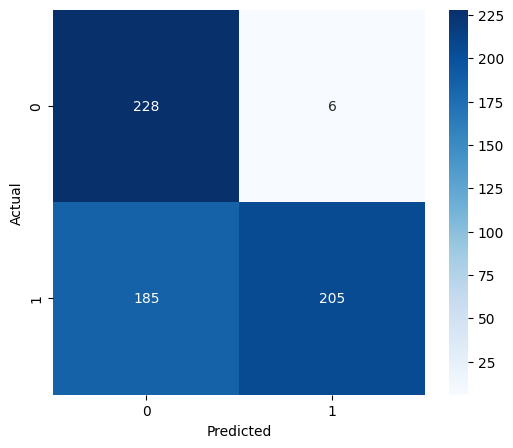

In [18]:
predictions = model.predict(test_data)

predicted_classes = (predictions > 0.5).astype("int32")

cm = confusion_matrix(
    test_data.classes,
    predicted_classes
)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
print(
    classification_report(
        test_data.classes,
        predicted_classes,
        target_names=['NORMAL','PNEUMONIA']
    )
)

              precision    recall  f1-score   support

      NORMAL       0.55      0.97      0.70       234
   PNEUMONIA       0.97      0.53      0.68       390

    accuracy                           0.69       624
   macro avg       0.76      0.75      0.69       624
weighted avg       0.81      0.69      0.69       624



In [20]:
model.save("/content/drive/MyDrive/pneumonia_cnn_model.h5")

print("Model Saved Successfully")

Model Saved Successfully
